# Atividade 6 — Join, Matplotlib, Melt (24/09/2026)

Junta as duas **Tabelas 5** (composição da desocupação por sexo, 2012 T1 e 2026 T1), compara ano a ano e cruza com a **Tabela 1.1.1** do IBGE (horas semanais de cuidados e afazeres domésticos, 2022 — já tratada na Aula 2).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Abrir e juntar as duas Tabelas 5

In [2]:
t2012 = pd.read_csv("Tabela5-sem_emprego_2012.csv", sep=";", decimal=",")
t2026 = pd.read_csv("Tabela5-sem_emprego_2026.csv", sep=";", decimal=",")

t2012 = t2012.rename(columns={"Desocupados - homens (2012 T1)": "homens_2012", "Desocupados - mulheres (2012 T1)": "mulheres_2012"})
t2026 = t2026.rename(columns={"Desocupados - homens (2026 T1)": "homens_2026", "Desocupados - mulheres (2026 T1)": "mulheres_2026"})

comp = t2012.merge(t2026, on=["Sigla", "Código", "Estado"], how="inner")
comp

,Sigla,Código,Estado,homens_2012,mulheres_2012,homens_2026,mulheres_2026
0,AC,12,Acre,45.3,54.7,53.2,46.8
1,AL,27,Alagoas,44.7,55.3,50.7,49.3
2,AM,13,Amazonas,47.5,52.5,46.8,53.2
3,AP,16,Amapá,48.1,51.9,51.1,48.9
4,BA,29,Bahia,43.8,56.2,44.7,55.3
5,CE,23,Ceará,51.1,48.9,52.7,47.3
6,DF,53,Distrito Federal,41.0,59.0,47.9,52.1
7,ES,32,Espírito Santo,46.4,53.6,47.5,52.5
8,GO,52,Goiás,41.0,59.0,47.5,52.5
9,MA,21,Maranhão,47.2,52.8,49.1,50.9


## 2. Gráfico: participação feminina entre os desocupados, 2012 x 2026

In [3]:
ordem = comp.sort_values("mulheres_2026", ascending=False)["Estado"]

longo = comp.melt(
    id_vars=["Sigla", "Código", "Estado", "homens_2012", "homens_2026"],
    value_vars=["mulheres_2012", "mulheres_2026"],
    var_name="Ano",
    value_name="Participacao_mulheres",
)
longo["Ano"] = longo["Ano"].map({"mulheres_2012": "2012 T1", "mulheres_2026": "2026 T1"})
longo

,Sigla,Código,Estado,homens_2012,homens_2026,Ano,Participacao_mulheres
0,AC,12,Acre,45.3,53.2,2012 T1,54.7
1,AL,27,Alagoas,44.7,50.7,2012 T1,55.3
2,AM,13,Amazonas,47.5,46.8,2012 T1,52.5
3,AP,16,Amapá,48.1,51.1,2012 T1,51.9
4,BA,29,Bahia,43.8,44.7,2012 T1,56.2
5,CE,23,Ceará,51.1,52.7,2012 T1,48.9
6,DF,53,Distrito Federal,41.0,47.9,2012 T1,59.0
7,ES,32,Espírito Santo,46.4,47.5,2012 T1,53.6
8,GO,52,Goiás,41.0,47.5,2012 T1,59.0
9,MA,21,Maranhão,47.2,49.1,2012 T1,52.8


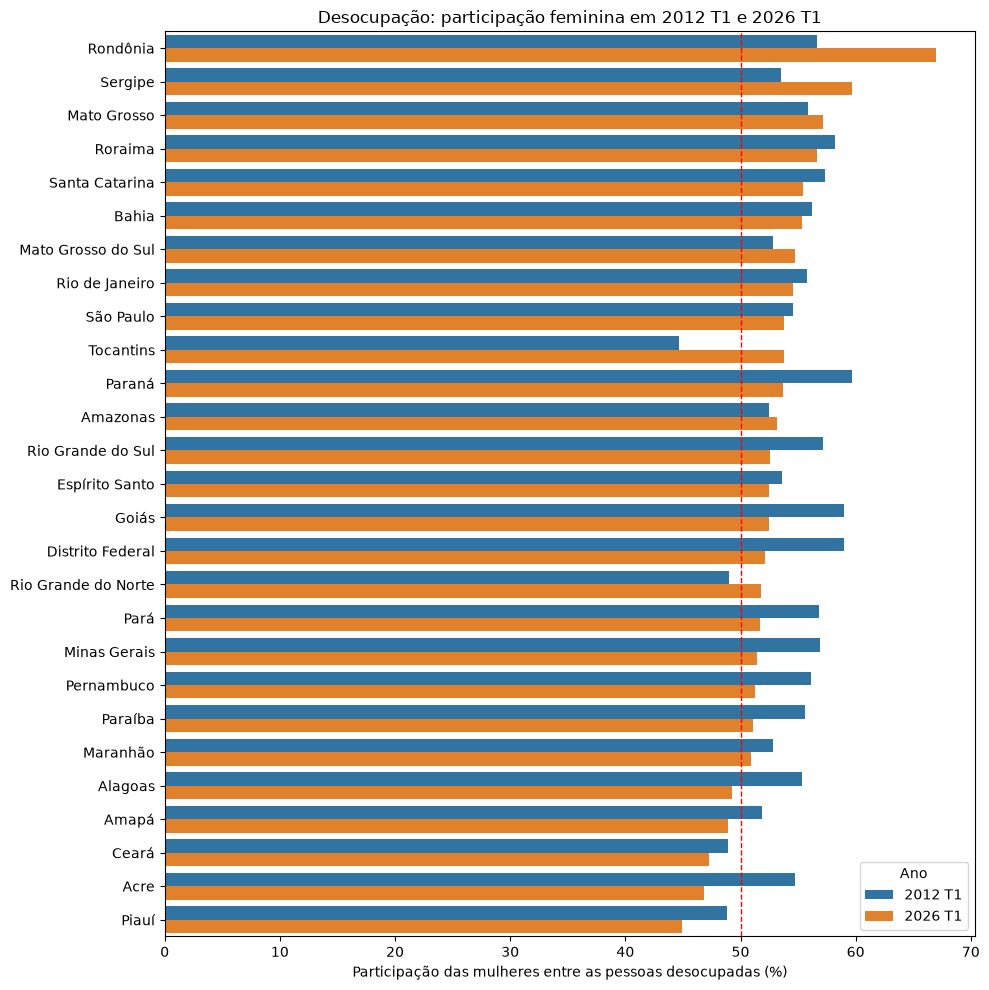

In [4]:
fig, ax = plt.subplots(figsize=(10, 10))
sns.barplot(
    data=longo,
    y="Estado",
    x="Participacao_mulheres",
    hue="Ano",
    order=ordem,
    ax=ax,
)
ax.axvline(50, color="red", linestyle="--", linewidth=1)
ax.set_xlabel("Participação das mulheres entre as pessoas desocupadas (%)")
ax.set_ylabel("")
ax.set_title("Desocupação: participação feminina em 2012 T1 e 2026 T1")
ax.legend(title="Ano")
fig.tight_layout()
plt.show()

## 3. Cruzar com a Tabela 1.1.1 (afazeres domésticos, Aula 2)

Reaproveitando a tabela já tratada na Aula 2 (`indicador_1`), filtrando **apenas os estados** (fora Brasil e as 5 Grandes Regiões).

In [5]:
indicador_1 = pd.DataFrame([
    ["Brasil", 16.985781, 16.545930, 17.333142, 11.705136, 11.746330, 20.404106, 22.037998],
    ["Norte", 16.187037, 15.925246, 16.256032, 11.588653, 11.514646, 19.295780, 20.534188],
    ["Rondônia", 17.014162, 16.727733, 17.101523, 12.111127, 12.544080, 20.412887, 21.061410],
    ["Acre", 13.606903, 13.806929, 13.541399, 10.796120, 9.686983, 16.130352, 16.710754],
    ["Amazonas", 16.807290, 15.987545, 16.995493, 12.233043, 12.822584, 18.764969, 20.716986],
    ["Roraima", 13.639257, 13.651755, 13.633606, 10.814803, 10.476601, 16.135877, 16.560244],
    ["Pará", 16.474268, 16.181627, 16.560239, 11.524306, 11.026707, 19.835110, 21.591144],
    ["Amapá", 13.586656, 14.389180, 13.415091, 11.116821, 10.749444, 16.648579, 15.908487],
    ["Tocantins", 15.815781, 15.701788, 15.768728, 10.733863, 11.682616, 19.663713, 19.629399],
    ["Nordeste", 18.499396, 18.151700, 18.610911, 11.723907, 11.848436, 22.744666, 23.716716],
    ["Maranhão", 16.669614, 16.421773, 16.708894, 11.665173, 11.437359, 19.881056, 20.739589],
    ["Piauí", 17.960366, 16.948094, 18.231789, 12.258324, 11.204814, 20.494063, 23.695440],
    ["Ceará", 19.499293, 18.527120, 19.882469, 12.186936, 12.821323, 23.019718, 24.952274],
    ["Rio Grande do Norte", 18.307740, 18.101853, 18.445218, 11.166909, 11.086286, 23.547080, 24.422884],
    ["Paraíba", 18.920816, 18.887920, 18.945306, 12.480204, 12.400831, 23.642936, 24.035650],
    ["Pernambuco", 19.306249, 18.950219, 19.418444, 12.312833, 12.868821, 23.357880, 24.243396],
    ["Alagoas", 20.217129, 19.165111, 20.560451, 12.121839, 13.357160, 24.093655, 25.856637],
    ["Sergipe", 18.826541, 17.264294, 19.317934, 10.830511, 11.270341, 21.740902, 25.637681],
    ["Bahia", 17.849776, 17.538007, 17.935566, 10.551673, 10.982808, 22.572730, 23.217119],
    ["Sudeste", 17.104218, 16.834863, 17.397989, 11.933522, 12.180843, 20.732969, 21.990431],
    ["Minas Gerais", 17.502141, 17.179387, 17.707564, 11.319720, 11.619120, 22.186650, 23.075751],
    ["Espírito Santo", 17.111106, 16.510610, 17.478861, 11.798571, 12.017589, 20.464462, 22.196626],
    ["Rio de Janeiro", 16.716263, 16.097467, 17.243060, 12.000036, 12.864896, 19.203741, 20.957728],
    ["São Paulo", 17.071295, 16.964437, 17.255480, 12.123044, 12.235200, 20.771186, 21.767620],
    ["Sul", 15.527769, 15.570983, 15.406088, 11.546629, 11.159487, 19.012969, 19.338734],
    ["Paraná", 15.390122, 15.453295, 15.307289, 11.240085, 10.815611, 18.896661, 19.365380],
    ["Santa Catarina", 16.039355, 16.124417, 15.616235, 12.339052, 11.517342, 19.414764, 19.646573],
    ["Rio Grande do Sul", 15.356709, 15.337269, 15.448203, 11.308447, 11.519941, 18.868230, 19.107720],
    ["Centro-Oeste", 15.000763, 14.826985, 15.078025, 10.546799, 10.332059, 18.220683, 19.331040],
    ["Mato Grosso do Sul", 15.309783, 14.902105, 15.567204, 10.446213, 11.126920, 18.593200, 19.542761],
    ["Mato Grosso", 14.239989, 14.083513, 14.270209, 9.479654, 9.265734, 17.782825, 18.695923],
    ["Goiás", 15.186471, 14.962622, 15.296966, 10.636424, 10.531883, 18.440842, 19.587913],
    ["Distrito Federal", 15.096351, 15.061306, 15.126295, 11.377952, 10.481279, 17.738123, 19.307332],
], columns=[
    "uf_regiao", "total", "total_branca", "total_preta_parda",
    "homem_branca", "homem_preta_parda", "mulher_branca", "mulher_preta_parda",
])

regioes = ["Norte", "Nordeste", "Sudeste", "Sul", "Centro-Oeste"]
estados_afazeres = indicador_1[~indicador_1["uf_regiao"].isin(["Brasil"] + regioes)]
estados_afazeres = estados_afazeres[["uf_regiao", "total"]].rename(columns={"total": "horas_afazeres_domesticos"})
estados_afazeres

,uf_regiao,horas_afazeres_domesticos
2,Rondônia,17.014162
3,Acre,13.606903
4,Amazonas,16.807290
5,Roraima,13.639257
6,Pará,16.474268
7,Amapá,13.586656
8,Tocantins,15.815781
10,Maranhão,16.669614
11,Piauí,17.960366
12,Ceará,19.499293


In [6]:
cruzado = comp.merge(estados_afazeres, left_on="Estado", right_on="uf_regiao", how="inner").drop(columns="uf_regiao")
cruzado = cruzado.sort_values("horas_afazeres_domesticos", ascending=False).reset_index(drop=True)
cruzado

,Sigla,Código,Estado,homens_2012,mulheres_2012,homens_2026,mulheres_2026,horas_afazeres_domesticos
0,AL,27,Alagoas,44.7,55.3,50.7,49.3,20.217129
1,CE,23,Ceará,51.1,48.9,52.7,47.3,19.499293
2,PE,26,Pernambuco,43.9,56.1,48.7,51.3,19.306249
3,PB,25,Paraíba,44.4,55.6,48.9,51.1,18.920816
4,SE,28,Sergipe,46.5,53.5,40.3,59.7,18.826541
5,RN,24,Rio Grande do Norte,51.0,49.0,48.2,51.8,18.307740
6,PI,22,Piauí,51.2,48.8,55.1,44.9,17.960366
7,BA,29,Bahia,43.8,56.2,44.7,55.3,17.849776
8,MG,31,Minas Gerais,43.1,56.9,48.6,51.4,17.502141
9,ES,32,Espírito Santo,46.4,53.6,47.5,52.5,17.111106


### Desocupação feminina (2026 T1) x horas de afazeres domésticos

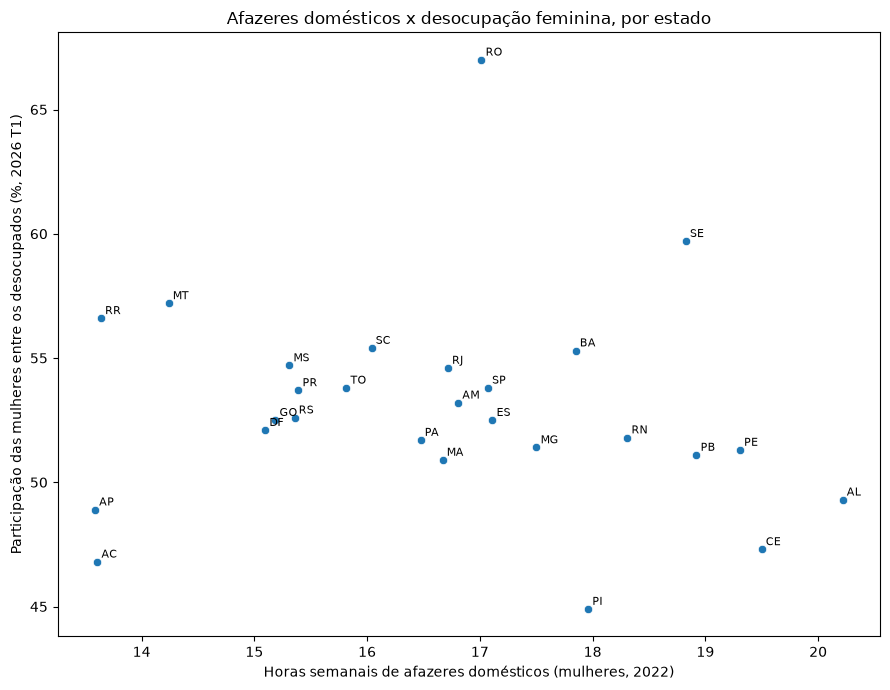

In [7]:
fig, ax = plt.subplots(figsize=(9, 7))
sns.scatterplot(
    data=cruzado,
    x="horas_afazeres_domesticos",
    y="mulheres_2026",
    ax=ax,
)
for _, linha in cruzado.iterrows():
    ax.annotate(linha["Sigla"], (linha["horas_afazeres_domesticos"], linha["mulheres_2026"]), fontsize=8, xytext=(3, 3), textcoords="offset points")

ax.set_xlabel("Horas semanais de afazeres domésticos (mulheres, 2022)")
ax.set_ylabel("Participação das mulheres entre os desocupados (%, 2026 T1)")
ax.set_title("Afazeres domésticos x desocupação feminina, por estado")
fig.tight_layout()
plt.show()

### Salvar em CSV

In [8]:
cruzado.to_csv("atividade6_cruzado.csv", sep=";", index=False)